# Germany smoke test — SIMPLACE vs torchcrop vs observations

~30 cropland cells across Germany, each in a distinct CyBench NUTS-3 region,
run by **both models over the same cells** so they differ only in the model.

Two references, and they are not the same kind of thing:

* **CyBench** — an administrative yield statistic over a whole NUTS-3 region,
  at market moisture (~13.5 %). A simulated cell is one point inside it, and
  the models report grain **dry matter**, so ~15 % of the reference is water
  that no correction is applied for here.
* **PEP725** — BBCH stage dates observed by volunteers at a station, matched to
  the nearest simulated cell within 25 km.

Neither pairing is exact, and the spread that comes from the mismatch is not
model error. Produce the inputs with:

```bash
./submit/submit_simplace.sh --smoke
python scripts/run_cells_torchcrop.py --config <smoke.yaml> \
    --cells <de_cells.csv> --out <de_torchcrop.parquet>
```

In [1]:
import logging
import sys
from pathlib import Path

# cropmodelling4eu is installed (pip install -e .), so the evaluation
# library is imported like any other package rather than off sys.path.

import numpy as np
import pandas as pd

from cropmodelling4eu.evaluation import aggregate, config, cybench, doy, metrics, plots, regions, torchcrop
from cropmodelling4eu.evaluation.style import use_style

logging.basicConfig(level=logging.INFO, format="%(levelname)s %(name)s: %(message)s",
                    force=True)
logging.getLogger("matplotlib").setLevel(logging.WARNING)

PALETTE = use_style("light")
config.ensure_output_dirs()

pd.set_option("display.max_rows", 60)
pd.set_option("display.width", 140)

print(f"TorchCrop run : {config.TORCHCROP_RUN_DIR}")
print(f"CyBench root  : {config.CYBENCH_ROOT}")
print(f"Outputs       : {config.OUTPUT_DIR}")

TorchCrop run : /data01/FDS/muduchuru/Data/SIMPLACE/torchcrop/winter_wheat_2000_2024
CyBench root  : /data01/FDS/muduchuru/Data/Agri/cybench
Outputs       : /data01/FDS/muduchuru/codes/GITHUB/data4simplace/cropmodelling4eu/src/cropmodelling4eu/outputs


In [2]:
from cropmodelling4eu.evaluation import germany

SMOKE = Path("/data01/FDS/muduchuru/Data/SIMPLACE/cropmodelling4eu/de_smoke")

cells = pd.read_csv(SMOKE / "de_cells.csv")
runs = germany.load_runs(
    simplace=SMOKE / "simplace" / "simplace_europe.parquet",
    torchcrop=SMOKE / "de_torchcrop.parquet",
)
lo, hi = germany.common_window(runs)
runs = {name: f[f["year"].between(lo, hi)] for name, f in runs.items()}

print(f"{len(cells)} cells, {cells['adm_id'].nunique()} NUTS-3 regions, "
      f"{cells['lon'].min():.2f}-{cells['lon'].max():.2f} E, "
      f"{cells['lat'].min():.2f}-{cells['lat'].max():.2f} N")
print(f"common window: {lo}-{hi}")
for name, frame in runs.items():
    print(f"  {name:10s} {len(frame):5d} rows, {frame['SimplaceID'].nunique()} cells")

30 cells, 30 NUTS-3 regions, 7.15-13.55 E, 48.35-53.95 N
common window: 2000-2010
  simplace     330 rows, 30 cells
  torchcrop    330 rows, 30 cells


## 1. Where the cells are

One cell per region, chosen nearest the centre of a 2-D lon/lat bin. Binning in
**two** dimensions matters: `SimplaceID` runs west-to-east within a row, so
taking the first cell of each latitude band walks the western border and
samples a climate gradient rather than the country.

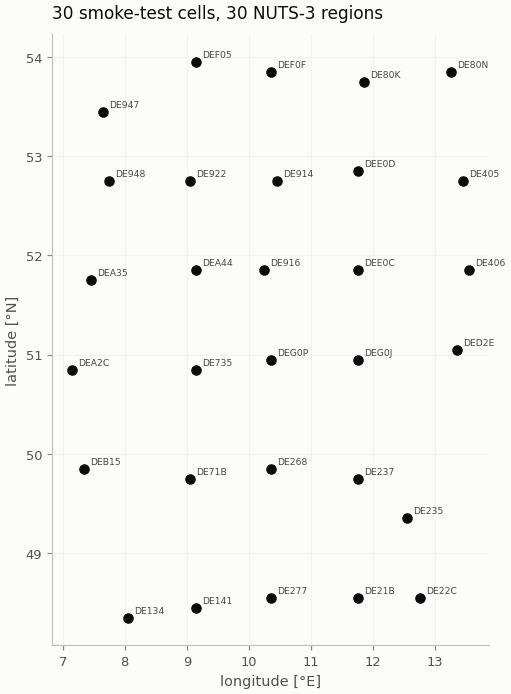

In [3]:
fig, ax = germany.plot_cells(cells, palette=PALETTE)
fig.savefig(config.FIGURE_DIR / "de_smoke_cells.png", dpi=150, bbox_inches="tight")

## 2. Yield vs CyBench

Paired on `(NUTS-3 region, harvest year)`. Bias is `simulated − observed`, so a
negative bias is an under-prediction — and remember ~15 % of the reference is
moisture the models do not report.

In [4]:
yields = germany.validate_yield(runs, cells)
display(yields[["model", "n", "regions", "years", "sim_mean", "obs_mean",
                "bias", "rmse", "mae", "r"]].round(2))
yields.to_csv(config.TABLE_DIR / "de_smoke_yield_vs_cybench.csv", index=False)

,model,n,regions,years,sim_mean,obs_mean,bias,rmse,mae,r
0,simplace,330.0,30,2000-2010,6.63,7.15,-0.53,1.71,1.36,0.32
1,torchcrop,330.0,30,2000-2010,1.99,7.15,-5.17,5.74,5.23,-0.14


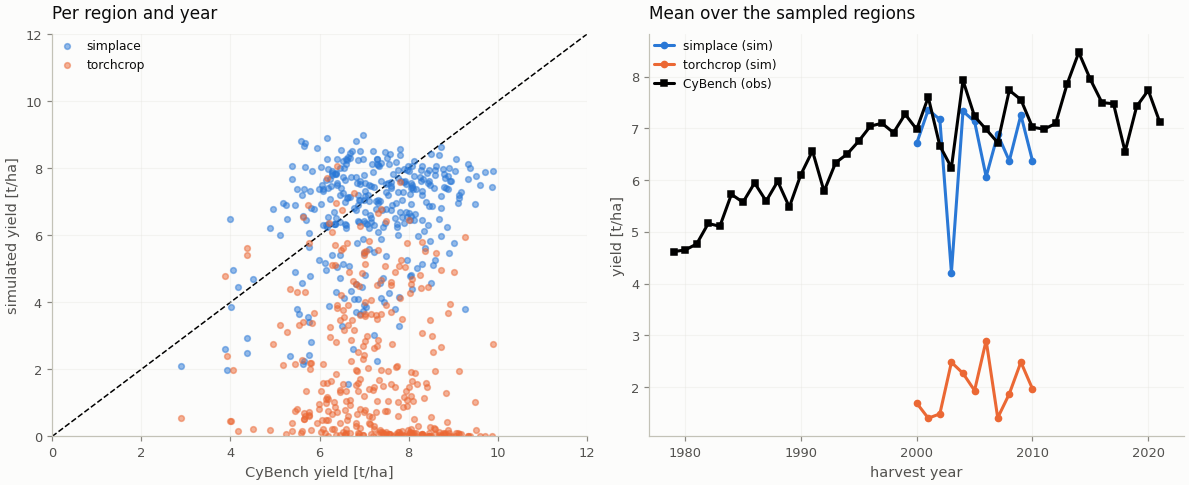

In [5]:
fig, axes = germany.plot_yield(runs, cells, palette=PALETTE)
fig.savefig(config.FIGURE_DIR / "de_smoke_yield.png", dpi=150, bbox_inches="tight")

## 3. Phenology vs PEP725

One observed date per `(cell, year)`: the median over the stations matched to
that cell, which is robust to a single mis-typed entry.

**Three rows are not model error and must not be read as such:**

* **Sowing is a constant input** in both runs, so its "bias" is one continental
  offset with no degrees of freedom — `r` is undefined because a constant has
  no variance. It still matters, because it propagates into every later stage.
* **Soft dough (BBCH 85) precedes full ripeness (BBCH 89)**, which is what the
  models report as maturity, so a positive bias of a couple of weeks is the
  expected sign.
* **Emergence** depends on the solution's `vTSUMEM`, not on the export.

Heading and harvest are the genuine tests: neither is an input.

In [6]:
observed = germany.load_pep725(cells, (lo, hi))
phenology = germany.validate_phenology(runs, observed)
display(phenology[["stage", "model", "n", "sim_mean", "obs_mean",
                   "bias", "rmse", "mae", "r"]].round(1))
phenology.to_csv(config.TABLE_DIR / "de_smoke_phenology_vs_pep725.csv", index=False)

for stage, caveat in phenology[["stage", "caveat"]].drop_duplicates().values:
    print(f"  {stage:24s} {caveat}")

INFO cropmodelling4eu.evaluation.germany: PEP725: 231 stations within 25 km of a simulated cell (of 1688)


,stage,model,n,sim_mean,obs_mean,bias,rmse,mae,r
0,Sowing (BBCH 00),simplace,324.0,273.2,279.9,-6.7,11.9,10.0,-0.1
1,Sowing (BBCH 00),torchcrop,324.0,270.0,279.9,-9.9,13.8,11.7,NaN
2,Emergence (BBCH 10),simplace,323.0,278.6,293.5,-14.9,18.5,16.0,-0.2
3,Heading (BBCH 51),simplace,322.0,172.7,150.9,21.8,24.7,22.4,0.7
4,Soft dough (BBCH 85),simplace,323.0,236.2,199.0,37.2,39.6,37.2,0.5
5,Soft dough (BBCH 85),torchcrop,323.0,183.7,199.0,-15.3,20.2,16.1,0.5
6,Harvest (PEP725 100),simplace,322.0,236.1,216.8,19.3,23.7,20.4,0.5
7,Harvest (PEP725 100),torchcrop,322.0,183.5,216.8,-33.3,36.0,33.3,0.4


  Sowing (BBCH 00)         rule-based in SIMPLACE, a constant input in torchcrop
  Emergence (BBCH 10)      first leaf through the sheath
  Heading (BBCH 51)        heading precedes anthesis by ~5-10 d
  Soft dough (BBCH 85)     precedes full ripeness (BBCH 89)
  Harvest (PEP725 100)     at or after maturity


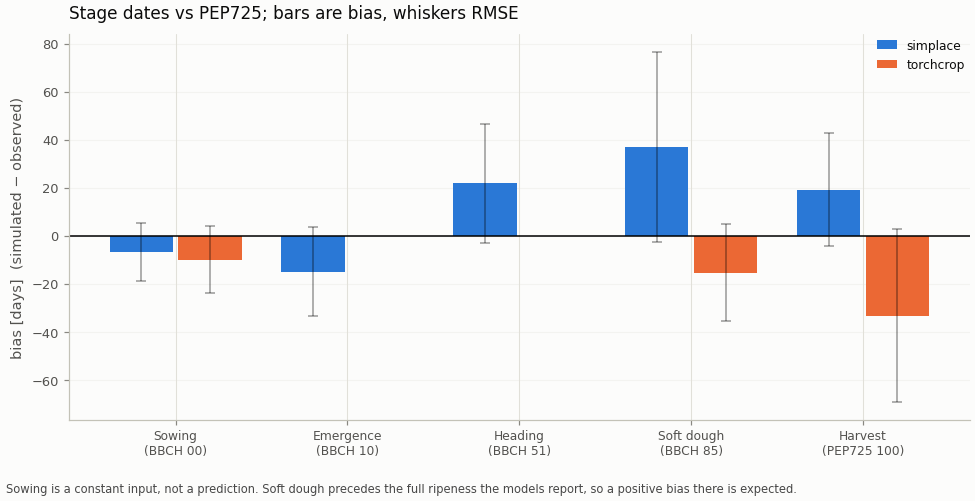

In [7]:
fig, axes = germany.plot_phenology(phenology, palette=PALETTE)
fig.savefig(config.FIGURE_DIR / "de_smoke_phenology.png", dpi=150, bbox_inches="tight")

## 4. Reading it

A short checklist, because the two references fail in different directions:

* **Yield level** is the weakest claim here — a regional statistic against one
  cell, on two different moisture bases. Treat a bias inside ~1 t/ha as
  "unbiased at national level" and nothing finer.
* **Interannual `r`** is the stronger claim: it needs no moisture correction and
  no area weighting, since both sides vary about their own mean. A run with a
  fixed sowing date, one CO₂ value and no cultivar calibration should not be
  expected to manage much above ~0.4.
* **A drought year is the useful single test.** 2003 is the one in this window;
  a model that misses it is not responding to water at all.
* **Heading and harvest bias** are the cleanest results the smoke test
  produces. If either drifts by more than ~2 weeks after a change to the
  export, the change is the first suspect.